# Compute metrics for different runs and plot them
##### author: Elizabeth A. Barnes, Randal J. Barnes and Mark DeMaria
##### version: v0.2.0

In [1]:
%matplotlib inline
%load_ext autotime
import os

import experiment_settings
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

dpiFig = 400
plt.style.use("seaborn-white")
mpl.rcParams["figure.dpi"] = 100
np.warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

time: 674 µs (started: 2022-12-16 05:36:27 -07:00)


In [2]:
__author__ = "Randal J Barnes and Elizabeth A. Barnes"
__version__ = "4 November 2022"

EXP_NAME_LIST = (

    # "bivariate_normal_000_EPCP24",

    "centered_bivariate_normal_100_EPCP12",
    "centered_bivariate_normal_101_EPCP24",
    "centered_bivariate_normal_102_EPCP36",
    "centered_bivariate_normal_103_EPCP48",
    "centered_bivariate_normal_104_EPCP60",
    "centered_bivariate_normal_105_EPCP72",
    "centered_bivariate_normal_106_EPCP84",
    "centered_bivariate_normal_107_EPCP96",
    "centered_bivariate_normal_108_EPCP108",
    "centered_bivariate_normal_109_EPCP120",

    "centered_bivariate_normal_200_AL12",
    "centered_bivariate_normal_201_AL24",
    "centered_bivariate_normal_202_AL36",
    "centered_bivariate_normal_203_AL48",
    "centered_bivariate_normal_204_AL60",
    "centered_bivariate_normal_205_AL72",
    "centered_bivariate_normal_206_AL84",
    "centered_bivariate_normal_207_AL96",
    "centered_bivariate_normal_208_AL108",
    "centered_bivariate_normal_209_AL120",

)
APPEND_NAME = ''


DATA_PATH = "data/"
MODEL_PATH = "saved_models/"
METRICS_PATH = "saved_metrics/"
FIGURE_PATH = "figures/analysis/"
PREDICTIONS_PATH = "saved_predictions/"

time: 464 µs (started: 2022-12-16 05:36:27 -07:00)


## Plotting functions

In [3]:
FS = 16

### for white background...
plt.rc('text', usetex=True)
plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Avant Garde']})
plt.rc('savefig', facecolor='white')
plt.rc('axes', facecolor='white')
plt.rc('axes', labelcolor='dimgrey')
plt.rc('axes', labelcolor='dimgrey')
plt.rc('xtick', color='dimgrey')
plt.rc('ytick', color='dimgrey')


################################
################################  
def adjust_spines(ax, spines):
    for loc, spine in ax.spines.items():
        if loc in spines:
            spine.set_position(('outward', 5))
        else:
            spine.set_color('none')
    if 'left' in spines:
        ax.yaxis.set_ticks_position('left')
    else:
        ax.yaxis.set_ticks([])
    if 'bottom' in spines:
        ax.xaxis.set_ticks_position('bottom')
    else:
        ax.xaxis.set_ticks([])


def format_spines(ax):
    adjust_spines(ax, ['left', 'bottom'])
    ax.spines['top'].set_color('none')
    ax.spines['right'].set_color('none')
    ax.spines['left'].set_color('dimgrey')
    ax.spines['bottom'].set_color('dimgrey')
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.tick_params('both', length=4, width=2, which='major', color='dimgrey')

#     ax.yaxis.grid(zorder=1,color='dimgrey',alpha=0.35)


time: 824 µs (started: 2022-12-16 05:36:27 -07:00)


## Get the dataframe

In [4]:
df_metrics = pd.DataFrame()

for exp_name in EXP_NAME_LIST:
    print(exp_name)
    settings = experiment_settings.get_settings(exp_name.split("_datasubset")[0])

    # set testing data
    if settings["test_condition"] == "leave-one-out":
        TESTING_YEARS_LIST = np.arange(2013, 2023)
    elif settings["test_condition"] == "years":
        TESTING_YEARS_LIST = (np.copy(settings["years_test"]))
    else:
        raise NotImplementedError('no such testing condition')

    for testing_years in TESTING_YEARS_LIST:
        # set testing year
        settings["years_test"] = (testing_years,)

        for rng_seed in settings["rng_seed_list"]:
            settings['rng_seed'] = rng_seed

            model_name = (
                    exp_name + "_" +
                    str(testing_years) + '_' +
                    settings["uncertainty_type"] + '_' +
                    f"rng_seed_{settings['rng_seed']}"
            )

            # load the metric filename
            metric_filename = METRICS_PATH + model_name + '_metrics.pickle'
            if not os.path.exists(metric_filename):
                metric_filename = METRICS_PATH + model_name + '_metrics.pkl'
                if not os.path.exists(metric_filename):
                    print(metric_filename + ' DOES NOT exist. Skipping...')
                    continue

            # pprint.pprint(model_name)
            df = pd.read_pickle(metric_filename)
            df_metrics = pd.concat([df_metrics, df])

# get best validation results            
idx = df_metrics.groupby(['exp_name', 'testing_years'], sort=False)['pit_D_valtest'].transform(min) == df_metrics['pit_D_valtest']
df_metrics_bestval = df_metrics[idx]

BEST_VAL_ONLY = True
if BEST_VAL_ONLY:
    print("**plotting only the best seed based on smallest pit_D**")
    df_metrics = df_metrics[idx]
    df_bestval = df_metrics[["exp_name", "basin_lead", "testing_years", "rng_seed"]]
    df_bestval.to_pickle(METRICS_PATH + "_best_validation_metrics.pickle")
else:
    APPEND_NAME = APPEND_NAME + "_allNetworks"

centered_bivariate_normal_100_EPCP12
centered_bivariate_normal_101_EPCP24
centered_bivariate_normal_102_EPCP36
centered_bivariate_normal_103_EPCP48
centered_bivariate_normal_104_EPCP60
saved_metrics/centered_bivariate_normal_104_EPCP60_2013_centered_bivariate_normal_rng_seed_1_metrics.pkl DOES NOT exist. Skipping...
saved_metrics/centered_bivariate_normal_104_EPCP60_2013_centered_bivariate_normal_rng_seed_2_metrics.pkl DOES NOT exist. Skipping...
saved_metrics/centered_bivariate_normal_104_EPCP60_2013_centered_bivariate_normal_rng_seed_3_metrics.pkl DOES NOT exist. Skipping...
saved_metrics/centered_bivariate_normal_104_EPCP60_2014_centered_bivariate_normal_rng_seed_1_metrics.pkl DOES NOT exist. Skipping...
saved_metrics/centered_bivariate_normal_104_EPCP60_2014_centered_bivariate_normal_rng_seed_2_metrics.pkl DOES NOT exist. Skipping...
saved_metrics/centered_bivariate_normal_104_EPCP60_2014_centered_bivariate_normal_rng_seed_3_metrics.pkl DOES NOT exist. Skipping...
saved_metrics/cen

In [5]:
df_metrics

,uncertainty_type,rng_seed,exp_name,basin_lead,testing_years,pit_D_test,sign_test_test,iqr_capture_test,mean_error_test,mean_error_reduction_test,...,pit_D_train,sign_test_train,iqr_capture_train,mean_error_train,mean_error_reduction_train,pit_D_valtest,sign_test_valtest,iqr_capture_valtest,mean_error_valtest,mean_error_reduction_valtest
0,centered_bivariate_normal,2,centered_bivariate_normal_100_EPCP12,EPCP12,2013,0.027288,0.511811,0.472441,45.879192,NaN,...,0.008253,0.495954,0.477748,39.844009,NaN,0.019157,0.482379,0.466960,43.395081,NaN
0,centered_bivariate_normal,1,centered_bivariate_normal_100_EPCP12,EPCP12,2014,0.023723,0.438202,0.447191,38.463806,NaN,...,0.011176,0.471712,0.468108,40.774956,NaN,0.018478,0.446512,0.471318,38.338295,NaN
0,centered_bivariate_normal,3,centered_bivariate_normal_100_EPCP12,EPCP12,2015,0.030154,0.582609,0.460870,45.746883,NaN,...,0.013106,0.467029,0.465580,39.647266,NaN,0.021234,0.542424,0.456061,43.109447,NaN
0,centered_bivariate_normal,1,centered_bivariate_normal_100_EPCP12,EPCP12,2016,0.030187,0.400000,0.480000,33.997005,NaN,...,0.017515,0.485461,0.467730,41.378750,NaN,0.026002,0.421667,0.486667,35.317684,NaN
0,centered_bivariate_normal,3,centered_bivariate_normal_100_EPCP12,EPCP12,2017,0.023255,0.425000,0.471429,38.477642,NaN,...,0.010549,0.470408,0.472109,40.641769,NaN,0.019275,0.441667,0.477083,38.316448,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,centered_bivariate_normal,2,centered_bivariate_normal_209_AL120,AL120,2018,0.079050,0.661157,0.322314,346.821320,0.0,...,0.018732,0.569498,0.445946,320.610748,0.0,0.049950,0.623053,0.380062,330.957397,0.0
0,centered_bivariate_normal,1,centered_bivariate_normal_209_AL120,AL120,2019,0.041119,0.520548,0.369863,266.845642,0.0,...,0.027190,0.607774,0.514134,329.494934,0.0,0.026770,0.578755,0.424908,314.357330,0.0
0,centered_bivariate_normal,3,centered_bivariate_normal_209_AL120,AL120,2020,0.029814,0.600000,0.416667,354.322968,0.0,...,0.021601,0.566474,0.452794,318.791534,0.0,0.032325,0.584375,0.418750,333.940277,0.0
0,centered_bivariate_normal,2,centered_bivariate_normal_209_AL120,AL120,2021,0.045890,0.486957,0.339130,325.800812,0.0,...,0.022552,0.587786,0.482824,330.178864,0.0,0.030590,0.539683,0.365079,315.238068,0.0


time: 10.7 ms (started: 2022-12-16 05:36:27 -07:00)


## Main figure

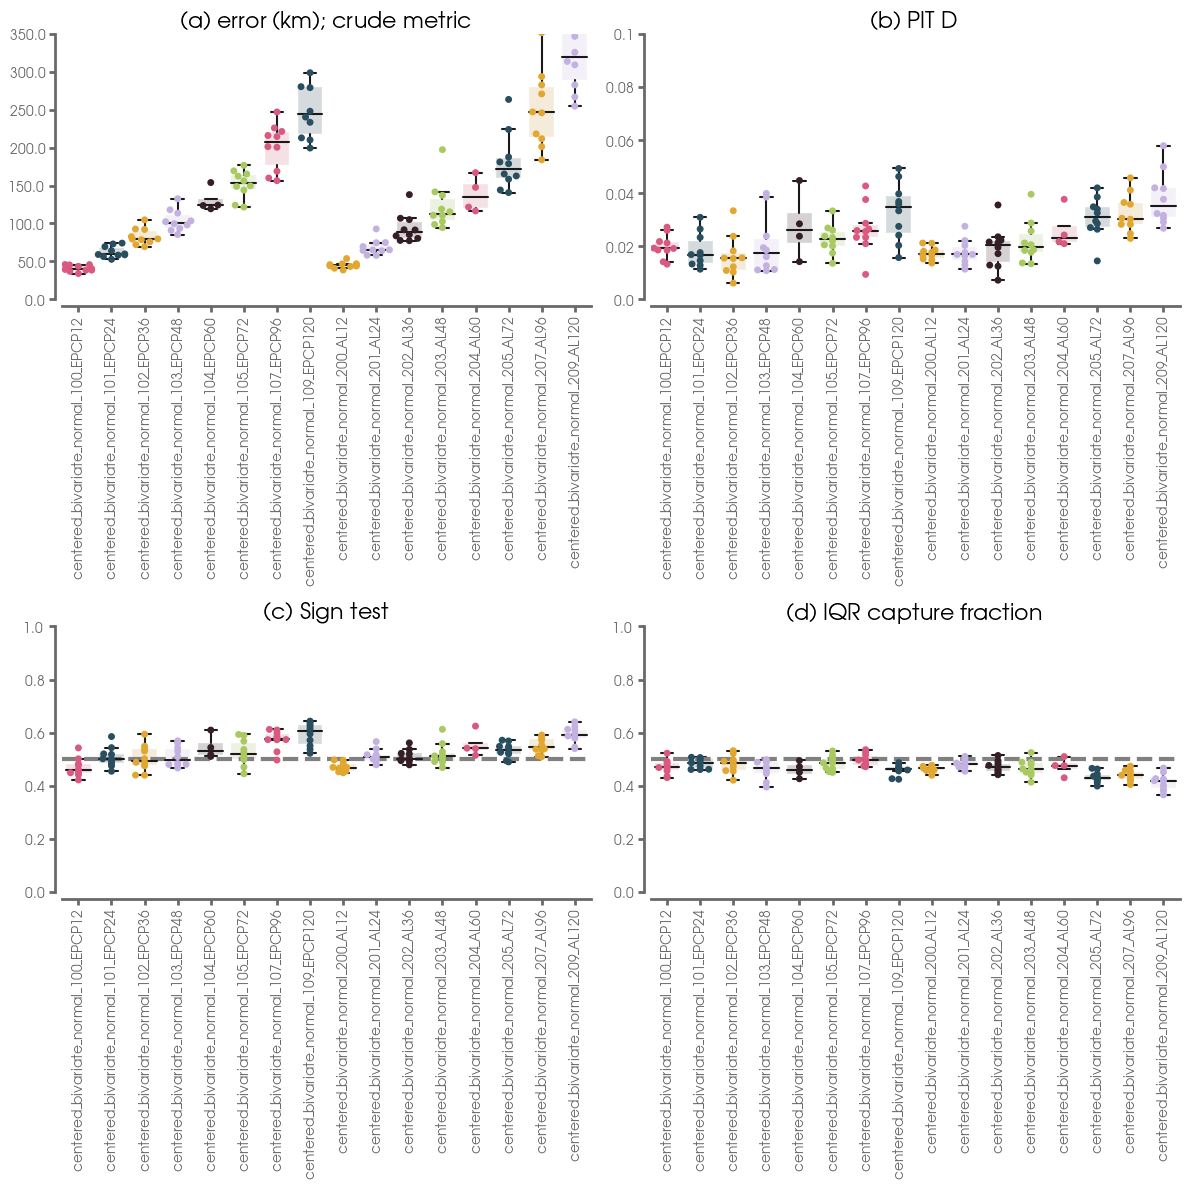

time: 7.29 s (started: 2022-12-16 05:36:27 -07:00)


In [6]:
FS_A = 10
colors = ('#D95980', '#284E60', '#E1A730', '#C3B1E1', '#351F27', '#A9C961')
panel_letters = ('(a)', '(b)', '(c)', '(d)')
x_axis_list = ("exp_name",)  #("basin_lead", "exp_name")

metric_data = ''
metric_list = ('mean_error_test',
               'pit_D_valtest',
               'sign_test_valtest',
               'iqr_capture_valtest',
               )
title_text = ('(a) error (km); crude metric',
              '(b) PIT D',
              '(c) Sign test',
              '(d) IQR capture fraction',
              )

for x_axis in x_axis_list:
    f, axs = plt.subplots(2, 2, figsize=(15 / 1.25, 1.5*10 / 1.25))
    axs = axs.flatten()

    for imetric, metric in enumerate([m + metric_data for m in metric_list]):
        ax = axs[imetric]
        g1 = sns.boxplot(x=x_axis,
                         y=metric,
                         hue="basin_lead",
                         data=df_metrics,
                         palette=colors,
                         width=.75,
                         dodge=False,
                         boxprops={'alpha': .2,
                                   'edgecolor': 'white',
                                   },
                         fliersize=0,
                         ax=ax)
        g2 = sns.swarmplot(x=x_axis,
                           y=metric,
                           hue="basin_lead",
                           palette=colors,
                           data=df_metrics,
                           dodge=False,
                           size=5,
                           ax=ax)

        if metric.find('iqr_capture') > -1:
            ax.axhline(y=0.5, linewidth=3, linestyle='--', color='gray')
            ax.set_ylim(0, 1.0)
        if metric.find('sign') > -1:
            ax.axhline(y=0.5, linewidth=3, linestyle='--', color='gray')
            ax.set_ylim(0, 1.0)
        if metric.find('pit_D') > -1:
            ax.set_ylim(0, .1)
        # if metric.find('reduction') > -1:
        #     ax.axhline(y=0.0, linewidth=3, linestyle='--', color='gray')
        #     ax.set_ylim(-4.5, 4.5)
        if metric.find('reduction') == -1 and metric.find('n_error') > -1:
            ax.set_ylim(0., 350.)
        if metric.find('iqr_error') > -1:
            ax.set_ylim(-.3, 1.)
            ax.axhline(y=0.0, linewidth=3, linestyle='--', color='gray')

        ax.set_title(title_text[imetric],
                     fontsize=FS,
                     color='k',
                     )

        ax.get_legend().remove()
        x_tick_labels = ax.get_xticklabels()
        yticks = np.around(ax.get_yticks(), 3)
        ax.set_yticklabels(yticks)
        ax.set_ylabel('')

        format_spines(ax)
        ax.set_xticklabels(x_tick_labels, rotation=90)
        ax.set_xlabel('')

    plt.tight_layout()
    plt.savefig(FIGURE_PATH + 'comparisonsMetrics' + APPEND_NAME + '.png', dpi=dpiFig)
    # plt.close()
    plt.show()

time: 7.29 s (started: 2022-12-16 05:36:27 -07:00)
